# One analytics question, three dataframe engines

**Guiding question:** Why can Pandas, Polars, and PySpark express the same analysis yet behave very differently?

Imagine that a product team needs a trustworthy list of movies to recommend. Our analytical question is:

> **Which movies are both highly rated and widely rated?**

We will build one query step by step, run the same work in three engines, verify that the answers agree, and then interpret the timing evidence. The goal is not to memorize a winner. By the end, you should be able to explain a result by asking:

1. **Where** does the work run—on one machine or across partitions that can span machines?
2. **When** does the work run—immediately or after a plan is built?
3. **How** does the engine organize the work—direct operations, parallel native execution, or scheduled tasks?

## Today’s 45-minute investigation

**Guiding question:** What evidence do we need before choosing a dataframe engine?

| Time | Question this section answers |
|---:|---|
| 0–4 | Are the environment, data, and comparison rules ready? |
| 4–9 | Can missing, duplicate, or differently scaled values distort the answer? |
| 9–15 | How do filtering, grouping, and aggregation change the shape of a table? |
| 15–21 | How does Pandas execute the complete query? |
| 21–26 | What changes when Polars uses a parallel native engine? |
| 26–34 | How does PySpark turn the query into partitioned tasks? |
| 34–40 | Do the answers match, and how does runtime change with scale? |
| 40–45 | Which execution model fits each workload? |

The storyline moves from **trustworthy data → shared operations → three execution models → verified evidence → a justified tool choice**. The optional Polars planning section comes after the 45-minute close.

## Establish a fair starting point

**Guiding question:** Are all three engines solving the same problem under the same conditions?

A useful comparison controls the inputs before it measures the outputs. The setup cell therefore:

- selects the deterministic 1M-row classroom dataset;
- defines **widely rated** as at least 1,000 ratings;
- confirms the files and Java runtime are available; and
- reports the library versions used for the run.

Without these controls, a different dataset, threshold, cache state, or environment could look like an engine difference. `FAST_DEMO = True` keeps the live lesson predictable; prepared results later provide the larger-scale evidence.

In [1]:
from pathlib import Path
import os, shutil, time, warnings

import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Keep unexpected warnings visible during class; suppress only known seaborn deprecations.
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
sns.set_theme(style="whitegrid", context="talk")
palette = sns.color_palette("colorblind", 4)
FRAMEWORK_COLORS = dict(
    zip(["Pandas", "Polars Eager", "Polars Lazy", "PySpark"], palette)
)

FAST_DEMO = True
MIN_RATINGS = 1_000
TOP_N = 10

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RATINGS_PATH = (
    ROOT
    / "data/parquet"
    / ("ratings_1m.parquet" if FAST_DEMO else "ratings_32m.parquet")
)
MOVIES_PATH = ROOT / "data/parquet/movies.parquet"
missing = [path for path in (RATINGS_PATH, MOVIES_PATH) if not path.exists()]
assert not missing, f"Missing {', '.join(map(str, missing))}; run `make data`."

# Make a Homebrew OpenJDK 17 installation visible to local PySpark.
for java_home in [
    Path("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
    Path("/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
]:
    if "JAVA_HOME" not in os.environ and java_home.exists():
        os.environ["JAVA_HOME"] = str(java_home)
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")
java_status = (
    "ready"
    if os.environ.get("JAVA_HOME") or shutil.which("java")
    else "not found (Spark will be skipped)"
)
print(f"Data: {RATINGS_PATH.name} | threshold: {MIN_RATINGS:,}")
print(f"Pandas {pd.__version__} | Polars {pl.__version__} | Java {java_status}")

Data: ratings_1m.parquet | threshold: 1,000
Pandas 3.0.5 | Polars 1.44.1 | Java ready


## 1. Understand the table before transforming it

**Guiding question:** What does one row represent, and which columns carry the meaning our query needs?

The **unit of observation** is one person’s rating of one movie:

| userId | movieId | rating | timestamp |
|---:|---:|---:|---:|
| 1 | 296 | 5.0 | … |
| 1 | 306 | 3.5 | … |

That definition tells us how to interpret every later operation. `movieId` is the key that connects a rating to a title, while `rating` supplies the value we will average. Repeated movie IDs are expected because many people can rate the same movie. The next cell checks the actual shape, schema, and sample rows before any information is reduced.

In [2]:
ratings = pd.read_parquet(RATINGS_PATH)
movies = pd.read_parquet(MOVIES_PATH)

print(
    f"{len(ratings):,} ratings • {ratings['userId'].nunique():,} users • {movies['movieId'].nunique():,} movies"
)
display(ratings[["userId", "movieId", "rating"]].head(5).style.hide(axis="index"))

1,000,000 ratings • 167,203 users • 87,585 movies


userId,movieId,rating
163692,201749,4.000000
63885,914,3.000000
197767,593,3.500000
140531,1291,4.000000
159429,265148,2.500000


### Test the data conditions used by this demo

**Guiding question:** Do missing values or exact duplicate rows threaten this aggregation?

The checks should follow from the meaning of a row:

- a missing `movieId` cannot join to a movie title;
- a missing `rating` changes the count and may change the average; and
- an exact duplicate counts the same stored event twice.

The next cell tests those conditions only. Repeated users and movie IDs are expected because many people rate many movies. A production pipeline should go further by checking repeated `(userId, movieId)` pairs, valid rating ranges, timestamp validity, and referential integrity with the movies table. If either demonstrated assertion fails, stop and choose an explicit repair policy before analysis.

In [3]:
quality_report = pd.DataFrame(
    {
        "data_type": ratings.dtypes.astype(str),
        "missing_values": ratings.isna().sum(),
        "distinct_values": ratings.nunique(),
    }
)
exact_duplicate_rows = int(ratings.duplicated().sum())

print(f"Exact duplicate rows: {exact_duplicate_rows:,}")
display(
    quality_report.style.format({"missing_values": "{:,}", "distinct_values": "{:,}"})
)

assert (
    quality_report["missing_values"].sum() == 0
), "Resolve missing values before benchmarking."
assert exact_duplicate_rows == 0, "Resolve exact duplicate rows before benchmarking."

Exact duplicate rows: 0


,data_type,missing_values,distinct_values
userId,int32,0,"167,203"
movieId,int32,0,"27,802"
rating,float32,0,10
timestamp,int64,0,"971,981"


### Decide whether normalization serves the analysis

**Guiding question:** How can we map ratings to 0–1, and does this query benefit from doing so?

MovieLens ratings use a 0.5-to-5.0 scale. Min–max normalization maps the endpoints to 0 and 1:

```text
normalized rating = (rating − 0.5) / (5.0 − 0.5)
```

Normalization is valuable when a model combines features with different units or ranges. Our ranking uses only ratings, so converting them would add work without adding information. Because this transformation is linear, it preserves ordering: the movie with the higher average star rating also has the higher average normalized rating. We calculate it as a teaching example, then keep stars in the final query because stars are easier to explain.

In [4]:
RATING_MIN, RATING_MAX = 0.5, 5.0
ratings_normalized = ratings.assign(
    rating_normalized=(ratings["rating"] - RATING_MIN) / (RATING_MAX - RATING_MIN)
)

assert ratings_normalized["rating_normalized"].between(0, 1).all()
display(
    ratings_normalized[["movieId", "rating", "rating_normalized"]]
    .head(8)
    .style.format({"rating": "{:.1f}", "rating_normalized": "{:.3f}"})
    .hide(axis="index")
)

movieId,rating,rating_normalized
201749,4.0,0.778
914,3.0,0.556
593,3.5,0.667
1291,4.0,0.778
265148,2.5,0.444
3005,3.0,0.556
319,0.5,0.000
1214,5.0,1.000


## Learn the first operation: filter rows

**Guiding question:** Which individual ratings are at least 4.5 stars, and what happens to the table’s shape?

A filter evaluates one Boolean condition per row. Rows that satisfy the condition remain; the columns stay the same unless we explicitly select fewer of them.

This 4.5-star filter is a small teaching example, **not** the final movie-ranking rule. The final query will compare average ratings after grouping. Before running the cell, predict whether `rating >= 4.5` keeps most rows or a minority, then compare your prediction with the reported count.

In [5]:
high_ratings = ratings.loc[
    ratings["rating"] >= 4.5,
    ["userId", "movieId", "rating"],
]
print(f"Pandas returned {len(high_ratings):,} matching rows immediately.")
display(high_ratings.head(5).style.hide(axis="index"))

Pandas returned 236,115 matching rows immediately.


userId,movieId,rating
121305,1214,5.000000
187312,1186,4.500000
14147,953,4.500000
80722,47,4.500000
109258,1213,4.500000


### Separate analytical intent from execution strategy

**Guiding question:** If three APIs describe the same filter, must they execute it in the same way?

```python
# Pandas
ratings.loc[ratings["rating"] >= 4.5, ["userId", "movieId", "rating"]]

# Polars
ratings.filter(pl.col("rating") >= 4.5).select("userId", "movieId", "rating")

# PySpark
ratings.filter(F.col("rating") >= 4.5).select("userId", "movieId", "rating")
```

All three snippets express the same **intent**: keep qualifying rows and three columns. The syntax alone does not tell us whether work starts immediately, uses several cores, or becomes scheduled partition tasks. Keep the operation constant while we add grouping; later we will change only the engine and observe how execution differs.

## Learn the second operation: group and aggregate

**Guiding question:** How do many rating events become one evidence summary per movie?

`group by movieId` places rows with the same movie key into the same logical group. Aggregation then reduces every group to two values:

```text
rating events → group by movieId → mean(rating) + count(rows)
```

The mean represents **how highly** a movie was rated; the count represents **how widely** it was rated. Predict the output shape before running the cell: the number of columns will change, and the number of rows will shrink from individual events to one row per rated movie.

In [6]:
movie_stats = (
    ratings.groupby("movieId")["rating"]
    .agg(average_rating="mean", rating_count="count")
    .reset_index()
)
print(f"One million input rows became {len(movie_stats):,} movie groups.")
display(
    movie_stats.head(8)
    .style.format({"average_rating": "{:.2f}", "rating_count": "{:,}"})
    .hide(axis="index")
)

One million input rows became 27,802 movie groups.


movieId,average_rating,rating_count
1,3.90,"2,171"
2,3.25,891
3,3.12,423
4,2.76,99
5,3.02,396
6,3.86,932
7,3.40,425
8,3.17,49


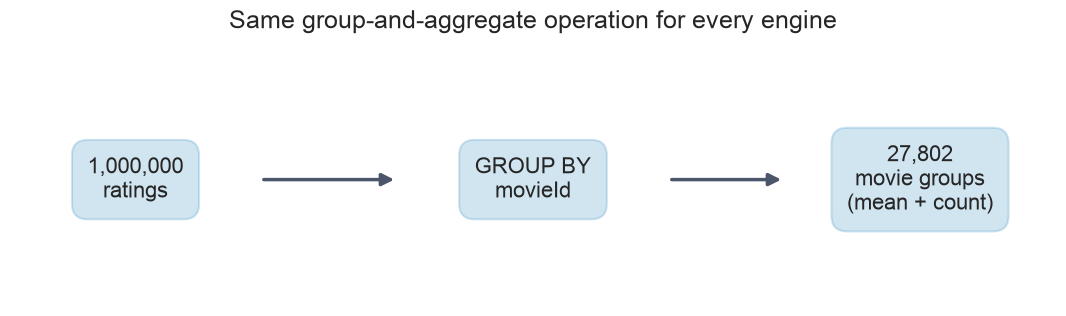

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis("off")

for start, end in [(0.24, 0.37), (0.63, 0.74)]:
    ax.annotate(
        "",
        xy=(end, 0.5),
        xytext=(start, 0.5),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color="#4C566A",
            lw=2.5,
            mutation_scale=18,
        ),
        zorder=1,
    )

steps = [
    (0.12, f"{len(ratings):,}\nratings"),
    (0.50, "GROUP BY\nmovieId"),
    (0.87, f"{len(movie_stats):,}\nmovie groups\n(mean + count)"),
]
for x, label in steps:
    ax.text(
        x,
        0.5,
        label,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=16,
        zorder=2,
        bbox=dict(
            boxstyle="round,pad=.7",
            facecolor=palette[0],
            alpha=0.18,
            edgecolor=palette[0],
        ),
    )

ax.set_title("Same group-and-aggregate operation for every engine", pad=18)
plt.tight_layout()
plt.show()

### Express one aggregation in three APIs

**Guiding question:** How does each engine say “produce one row per movie with a mean and a count”?

```python
# Pandas
ratings.groupby("movieId").agg(average_rating=("rating", "mean"), rating_count=("rating", "count"))

# Polars
ratings.group_by("movieId").agg(pl.col("rating").mean(), pl.len())

# PySpark
ratings.groupBy("movieId").agg(F.avg("rating"), F.count("*"))
```

Method names and punctuation differ, but each expression defines the same input groups and output summaries. That semantic equivalence is what makes the later correctness and runtime comparisons meaningful. We can now turn “highly rated and widely rated” into one complete, testable pipeline.

## Assemble the shared analytical pipeline

**Guiding question:** Which widely rated movies have the highest average ratings?

An average without its sample size can mislead. We define **widely rated** as at least 1,000 stored ratings. Among eligible movies, **highly rated** means appearing near the top when sorted by average rating:

```text
read ratings → group by movieId → calculate mean + count
             → keep count ≥ 1,000 → join movie titles
             → sort by mean, count, and movieId → materialize the result
```

The count threshold excludes averages based on only a few stored events; it does not prove statistical reliability or remove selection bias. Count and `movieId` provide deterministic tie-breakers after average rating. Every engine will execute this same workload against the same files.

## 2. Establish the Pandas reference

**Guiding question:** Where does Pandas perform the work, and when does each operation run?

Pandas provides an eager, local dataframe model: each step is evaluated on one machine as the program reaches it, and the resulting dataframe is held in memory. Vectorized operations move most row-wise work out of Python loops, but the working set still needs to fit comfortably in local memory.

```text
Python request → eager local operations → in-memory result
```

We start here because Pandas is familiar and its output is easy to inspect. The next cell executes the complete pipeline; that sorted result becomes the reference that the other engines must match.

In [8]:
# Live timings use one cold, end-to-end run: read files, execute, and materialize the result.
pandas_start = time.perf_counter()
pandas_ratings = pd.read_parquet(RATINGS_PATH, columns=["movieId", "rating"])
pandas_movies = pd.read_parquet(MOVIES_PATH, columns=["movieId", "title"])
pandas_result = (
    pandas_ratings.groupby("movieId")
    .agg(average_rating=("rating", "mean"), rating_count=("rating", "count"))
    .query("rating_count >= @MIN_RATINGS")
    .reset_index()
    .merge(pandas_movies, on="movieId")
    .sort_values(
        ["average_rating", "rating_count", "movieId"], ascending=[False, False, True]
    )
    .reset_index(drop=True)
)
pandas_runtime = time.perf_counter() - pandas_start
LIVE_ROWS = len(pandas_ratings)

display(
    pandas_result.head(TOP_N)[["title", "average_rating", "rating_count"]]
    .style.format({"average_rating": "{:.2f}", "rating_count": "{:,}"})
    .hide(axis="index")
)

title,average_rating,rating_count
"Shawshank Redemption, The (1994)",4.38,"3,212"
"Godfather, The (1972)",4.31,"2,000"
"Godfather: Part II, The (1974)",4.27,"1,332"
Schindler's List (1993),4.27,"2,337"
"Usual Suspects, The (1995)",4.24,"2,068"
Spirited Away (Sen to Chihiro no kamikakushi) (2001),4.23,"1,041"
One Flew Over the Cuckoo's Nest (1975),4.22,"1,371"
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.21,"1,008"
Fight Club (1999),4.20,"2,393"
Pulp Fiction (1994),4.20,"2,989"


### Sanity-check the reference answer

**Guiding question:** Which movies rank highest after the 1,000-rating eligibility filter?

A successful run is not automatically a sensible result. Verify that every displayed movie clears the count threshold, then compare how close the leading averages are. The threshold establishes eligibility; the descending average determines rank.

The table preserves the exact sorted values, while the chart makes small differences among the leaders easier to discuss. This inspected Pandas output becomes the reference for comparing movie IDs, counts, and average ratings across engines.

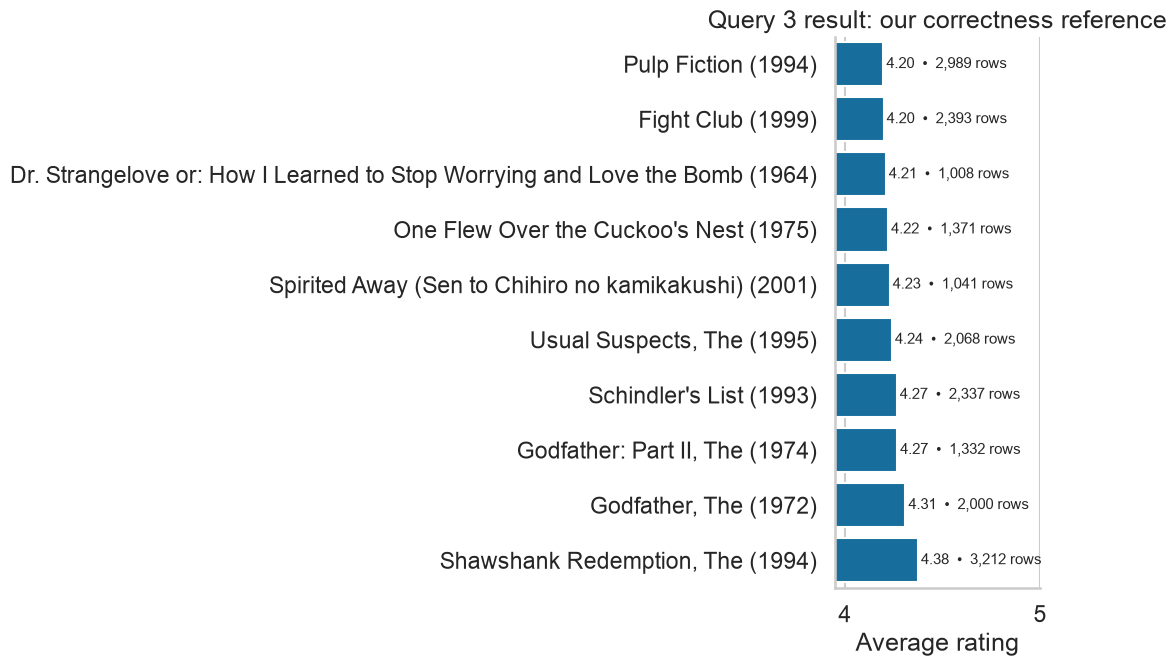

In [9]:
top_movies = pandas_result.head(TOP_N).sort_values("average_rating")
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=top_movies,
    x="average_rating",
    y="title",
    color=FRAMEWORK_COLORS["Pandas"],
    ax=ax,
)
ax.set(
    title="Query 3 result: our correctness reference",
    xlabel="Average rating",
    ylabel="",
)
ax.set_xlim(max(0, top_movies.average_rating.min() - 0.25), 5)
for bar, (_, row) in zip(ax.patches, top_movies.iterrows()):
    ax.text(
        row.average_rating + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{row.average_rating:.2f}  •  {row.rating_count:,.0f} rows",
        va="center",
        fontsize=11,
    )
sns.despine()
plt.tight_layout()
plt.show()

## 3. Keep the workload fixed and switch to Polars

**Guiding question:** What changes when the same local query runs through a parallel native engine?

The analytical steps remain unchanged: read, group, aggregate, filter, join, sort, and materialize. What changes is the execution layer. Polars represents column work as expressions and performs it in a native engine designed to use multiple CPU cores efficiently.

```text
Python expressions → parallel native engine → materialized result
```

This section uses the standard eager-facing Polars API so the main lesson stays focused on engine architecture, not API modes. Predict whether less Python overhead and more parallel work will matter at 1M rows, then compare the result and end-to-end runtime.

In [10]:
polars_start = time.perf_counter()
pl_ratings = pl.read_parquet(RATINGS_PATH, columns=["movieId", "rating"])
pl_movies = pl.read_parquet(MOVIES_PATH, columns=["movieId", "title"])
polars_result = (
    pl_ratings.group_by("movieId")
    .agg(
        pl.col("rating").mean().alias("average_rating"), pl.len().alias("rating_count")
    )
    .filter(pl.col("rating_count") >= MIN_RATINGS)
    .join(pl_movies, on="movieId")
    .sort(["average_rating", "rating_count", "movieId"], descending=[True, True, False])
)
polars_runtime = time.perf_counter() - polars_start
polars_result.head(TOP_N)

movieId,average_rating,rating_count,title
i32,f32,u32,str
318,4.375311,3212,"""Shawshank Redemption, The (199…"
858,4.31075,2000,"""Godfather, The (1972)"""
1221,4.268394,1332,"""Godfather: Part II, The (1974)"""
527,4.266581,2337,"""Schindler's List (1993)"""
50,4.242021,2068,"""Usual Suspects, The (1995)"""
5618,4.230067,1041,"""Spirited Away (Sen to Chihiro …"
1193,4.222101,1371,"""One Flew Over the Cuckoo's Nes…"
750,4.210318,1008,"""Dr. Strangelove or: How I Lear…"
2959,4.199122,2393,"""Fight Club (1999)"""


## 4. Turn the same query into partitioned PySpark work

**Guiding question:** How does PySpark transform a dataframe request into tasks, and what fixed costs does that introduce?

PySpark first describes **what** result is required. Spark then chooses **how** to produce it:

```text
Python API → logical plan → Catalyst optimization → physical stages → executor tasks
```

The **driver** plans and coordinates the job. **Executors** process partitions, which are chunks of data that can be handled independently. In this demo, driver and executor work stay on one laptop; in production, the same task model can extend across machines.

Before running the cell, make a prediction: at only 1M rows, will partitioned execution save more time than JVM startup, planning, scheduling, and coordination consume?

In [11]:
spark_result = spark_result_pd = None
spark_runtime = spark = None
try:
    from pyspark.sql import SparkSession, functions as F

    spark_start = (
        time.perf_counter()
    )  # Cold, end-to-end: startup, reads, query, and collection.
    spark = (
        SparkSession.builder.master("local[*]")
        .appName("MovieLens TA demo")
        .config("spark.ui.enabled", "false")
        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("ERROR")
    sr, sm = spark.read.parquet(str(RATINGS_PATH)), spark.read.parquet(str(MOVIES_PATH))
    spark_result = (
        sr.groupBy("movieId")
        .agg(
            F.avg("rating").alias("average_rating"), F.count("*").alias("rating_count")
        )
        .filter(F.col("rating_count") >= MIN_RATINGS)
        .join(sm.select("movieId", "title"), "movieId")
        .orderBy(F.desc("average_rating"), F.desc("rating_count"), F.asc("movieId"))
    )
    spark_result_pd = spark_result.toPandas()
    spark_runtime = time.perf_counter() - spark_start
    display(spark_result_pd.head(TOP_N))
except Exception as exc:
    spark_result = spark_result_pd = None
    print(f"Spark skipped: {type(exc).__name__}: {exc}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/.venv/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/27 14:03:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,movieId,average_rating,rating_count,title
0,318,4.375311,3212,"Shawshank Redemption, The (1994)"
1,858,4.310750,2000,"Godfather, The (1972)"
2,1221,4.268393,1332,"Godfather: Part II, The (1974)"
3,527,4.266581,2337,Schindler's List (1993)
4,50,4.242021,2068,"Usual Suspects, The (1995)"
5,5618,4.230067,1041,Spirited Away (Sen to Chihiro no kamikakushi) ...
6,1193,4.222101,1371,One Flew Over the Cuckoo's Nest (1975)
7,750,4.210317,1008,Dr. Strangelove or: How I Learned to Stop Worr...
8,2959,4.199122,2393,Fight Club (1999)
9,296,4.197892,2989,Pulp Fiction (1994)


### Explain Spark’s small-data result

**Guiding question:** Why might a scalable distributed engine be slower in this one-laptop run?

The measured boundary includes several fixed or coordination costs:

- start or connect to the JVM and create a session;
- analyze and optimize the logical plan;
- divide stages into tasks and schedule partitions;
- execute shuffles and joins; and
- collect the small final result back to the driver.

Because 1M rows fit comfortably on this laptop, these are plausible explanations for the observed runtime, but the total timing does not isolate each cost. The next output is a **conceptual stage summary**—scan → partial aggregate → shuffle → final aggregate → join → sort—not a captured physical plan. Use `explain("formatted")` when the actual optimized plan is the teaching objective.

In [12]:
if spark_result is not None:
    display(Markdown("""
**Plan to read aloud:** Parquet scan → partial aggregate → shuffle → final aggregate → join → sort

Spark also projects the required columns and uses adaptive execution. Run
`spark_result.explain("formatted")` after class to inspect the full physical plan.
"""))


**Plan to read aloud:** Parquet scan → partial aggregate → shuffle → final aggregate → join → sort

Spark also projects the required columns and uses adaptive execution. Run
`spark_result.explain("formatted")` after class to inspect the full physical plan.


## 5. Verify computed values before comparing speed

**Guiding question:** What must agree before runtime numbers are comparable?

A faster result is irrelevant if a join, filter, sort direction, or numeric conversion changed the semantics. The next cell aligns rows by `movieId` and compares `average_rating` and `rating_count`, allowing small floating-point differences and ignoring dtype differences.

Be precise about the evidence: these assertions verify the ranked IDs and numeric summaries, but they do not independently validate title text. Once the computed values agree, we can move from correctness to timing with a clearly stated measurement boundary.

In [13]:
def comparable(frame):
    return (
        frame[["movieId", "average_rating", "rating_count"]]
        .sort_values("movieId")
        .reset_index(drop=True)
    )


pd.testing.assert_frame_equal(
    comparable(pandas_result),
    comparable(polars_result.to_pandas()),
    check_dtype=False,
    atol=1e-6,
    rtol=1e-6,
)
print("✓ Pandas matches Polars")
if spark_result_pd is not None:
    pd.testing.assert_frame_equal(
        comparable(pandas_result),
        comparable(spark_result_pd),
        check_dtype=False,
        atol=1e-6,
        rtol=1e-6,
    )
    print("✓ PySpark matches")

✓ Pandas matches Polars
✓ PySpark matches


### Separate live observations from prepared benchmark evidence

**Guiding question:** Which timings come from this session, and which were recorded beforehand?

The next cell first displays the one-shot live timings collected while producing each result. It then loads prepared measurements from `results/benchmark_results_simple.csv`.

- **Live run:** one end-to-end classroom observation; useful for seeing startup and execution, but too noisy for ranking.
- **Prepared benchmark:** median runtime from three end-to-end runs at each tested size; useful for discussing the recorded scaling pattern.

Both use the boundary **read → group → aggregate → filter → join → sort → materialize**. Benchmark conclusions still depend on provenance: hardware, software versions, input construction, repetition count, cache state, and startup policy. Treat the chart as evidence for this recorded setup, not as a universal ranking.

Live demo — one cold, end-to-end run (do not treat as a ranking)


framework,rows,runtime_seconds
Pandas,"1,000,000",0.028
Polars Eager,"1,000,000",0.070
PySpark,"1,000,000",4.770


Polars Eager is already faster at 100 rows; the crossover is below the tested range for this workload.
Polars Lazy is already faster at 100 rows; the crossover is below the tested range for this workload.


rows,Pandas,Polars Eager,Polars Lazy,Polars Eager speedup,Polars Lazy speedup
100,0.0074s,0.0049s,0.0047s,1.50×,1.57×
"200,000",0.0109s,0.0067s,0.0044s,1.62×,2.50×
"500,000",0.0142s,0.0080s,0.0044s,1.77×,3.22×
"1,000,000",0.0197s,0.0096s,0.0062s,2.05×,3.18×


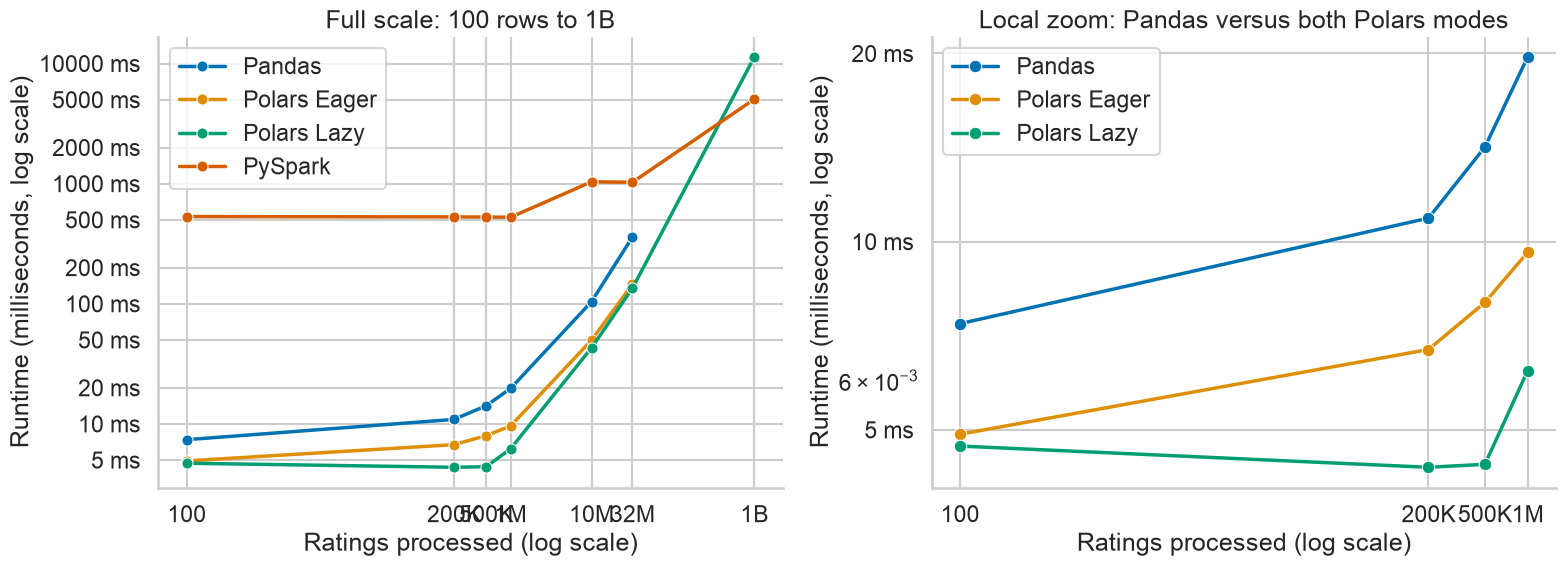

In [14]:
prepared = pd.read_csv(ROOT / "results/benchmark_results_simple.csv")

# Show this session separately; never overwrite repeatable benchmark results with one-shot timings.
live = pd.DataFrame(
    [
        {"framework": framework, "rows": LIVE_ROWS, "runtime_seconds": runtime}
        for framework, runtime in {
            "Pandas": pandas_runtime,
            "Polars Eager": polars_runtime,
            "PySpark": spark_runtime,
        }.items()
        if runtime is not None
    ]
)
print("Live demo — one cold, end-to-end run (do not treat as a ranking)")
display(
    live.style.format({"rows": "{:,}", "runtime_seconds": "{:.3f}"}).hide(axis="index")
)

polars_modes = ["Polars Eager", "Polars Lazy"]
local_comparison = (
    prepared[prepared["framework"].isin(["Pandas", *polars_modes])]
    .pivot(index="rows", columns="framework", values="runtime_seconds")
    .dropna()
    .reset_index()
)
smallest_test = local_comparison["rows"].min()
for mode in polars_modes:
    speedup_column = f"{mode} speedup"
    local_comparison[speedup_column] = (
        local_comparison["Pandas"] / local_comparison[mode]
    )
    first_win = local_comparison.loc[
        local_comparison[mode] < local_comparison["Pandas"], "rows"
    ].min()
    if first_win == smallest_test:
        print(
            f"{mode} is already faster at {first_win:,} rows; "
            "the crossover is below the tested range for this workload."
        )
    else:
        print(f"First observed {mode} win: {first_win:,} rows")

comparison_formats = {
    "rows": "{:,}",
    "Pandas": "{:.4f}s",
    **{mode: "{:.4f}s" for mode in polars_modes},
    **{f"{mode} speedup": "{:.2f}×" for mode in polars_modes},
}
display(
    local_comparison[local_comparison["rows"] <= 1_000_000]
    .style.format(comparison_formats)
    .hide(axis="index")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=prepared,
    x="rows",
    y="runtime_seconds",
    hue="framework",
    marker="o",
    palette=FRAMEWORK_COLORS,
    linewidth=2.5,
    markersize=8,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set(
    title="Full scale: 100 rows to 1B",
    xlabel="Ratings processed (log scale)",
    ylabel="Runtime (milliseconds, log scale)",
)
axes[0].set_xticks(
    [100, 200_000, 500_000, 1_000_000, 10_000_000, 32_000_000, 1_024_006_528],
    labels=["100", "200K", "500K", "1M", "10M", "32M", "1B"],
)
axes[0].legend(title="")

small_local = prepared[
    prepared["framework"].isin(["Pandas", *polars_modes])
    & (prepared["rows"] <= 1_000_000)
]
sns.lineplot(
    data=small_local,
    x="rows",
    y="runtime_seconds",
    hue="framework",
    marker="o",
    palette=FRAMEWORK_COLORS,
    linewidth=2.5,
    markersize=9,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set(
    title="Local zoom: Pandas versus both Polars modes",
    xlabel="Ratings processed (log scale)",
    ylabel="Runtime (milliseconds, log scale)",
)
axes[1].set_xticks(
    [100, 200_000, 500_000, 1_000_000],
    labels=["100", "200K", "500K", "1M"],
)
axes[1].legend(title="")

from matplotlib.ticker import FuncFormatter, LogLocator

milliseconds_formatter = FuncFormatter(lambda value, _: f"{value * 1_000:g} ms")
for ax in axes:
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
    ax.yaxis.set_major_formatter(milliseconds_formatter)

sns.despine()
plt.tight_layout()
plt.show()

### Read the observed scaling pattern—not a universal ranking

**Guiding question:** How do eager and lazy Polars compare with Pandas, and what remains untested?

Read the evidence in three passes:

1. **Tiny and intermediate inputs:** the right chart isolates Pandas, Polars Eager, and Polars Lazy at 100, 200K, 500K, and 1M rows.
2. **Planning effect:** compare the two Polars lines. The lazy path can optimize the complete query before `collect()` materializes it; the eager path executes the standard step-by-step API used in the core demo.
3. **Extreme input volume:** the synthetic 1B-row source repeats the 32M-row ratings file as 32 Parquet partitions. It stresses partition processing but does not represent one billion independent rating events.

Both Polars modes are already faster than Pandas at **100 rows**, the smallest shared input, so no Pandas–Polars crossover was observed within the tested range. This does not establish what happens below 100 rows or for another workload.

At 1B synthetic rows, local PySpark is recorded at about **5.05 seconds** and **Polars Lazy** at **11.32 seconds**. Pandas and Polars Eager were not run there, and local Spark does not demonstrate multi-machine scaling. Startup policy, cache state, data shape, operation mix, memory pressure, partitioning, and deployment can all change the relationship.

## 6. Connect the timings to the demonstrated execution models

**Guiding question:** Where does work run, when is it triggered, and how is it organized in each pipeline?

The API is only the instruction surface; the demonstrated mode determines how work is organized:

- **Pandas:** the standard operations shown here execute eagerly on one machine; native kernels do much of the work, while parallelism varies by operation and dependency.
- **Polars Eager:** expressions execute through a parallel native engine as each eager result is requested.
- **Polars Lazy:** expressions build an optimizable plan, and `collect()` triggers execution on one machine.
- **PySpark:** transformations build a logical plan, and an action schedules partition tasks locally here or across executors in a cluster.

Do not reduce these models to “slow” and “fast.” Each trades simplicity, planning, parallelism, coordination, and scalability differently. The following table is a teaching mental model for the exact modes used in this demo, not a hard data-size cutoff.

In [15]:
framework_summary = pd.DataFrame(
    [
        [
            "Pandas",
            "As each operation is requested",
            "One machine",
            "Calls local native operations",
        ],
        [
            "Polars Eager",
            "As each result is requested",
            "One machine, parallel",
            "Sends expressions to a native engine",
        ],
        [
            "Polars Lazy",
            "When collect() is called",
            "One machine, planned and parallel",
            "Builds an optimizable expression plan",
        ],
        [
            "PySpark",
            "When an action is called",
            "One or many machines",
            "Builds a logical plan for Spark",
        ],
    ],
    columns=["Framework", "When work runs", "Designed scale", "Role of Python"],
)

framework_summary.style.hide(axis="index").set_properties(**{"text-align": "left"})

Framework,When work runs,Designed scale,Role of Python
Pandas,As each operation is requested,One machine,Calls local native operations
Polars Eager,As each result is requested,"One machine, parallel",Sends expressions to a native engine
Polars Lazy,When collect() is called,"One machine, planned and parallel",Builds an optimizable expression plan
PySpark,When an action is called,One or many machines,Builds a logical plan for Spark


### Trace one instruction through each stack

**Guiding question:** After Python expresses a dataframe operation, which component actually performs the expensive work?

Read the next diagram from left to right. In every case, Python expresses the request, but the computation follows a different path before a result appears. As you compare the paths, identify:

- where planning occurs;
- where parallelism can occur; and
- which coordination costs exist before rows are processed.

This is the bridge between the similar syntax we wrote and the different scaling behavior we measured.

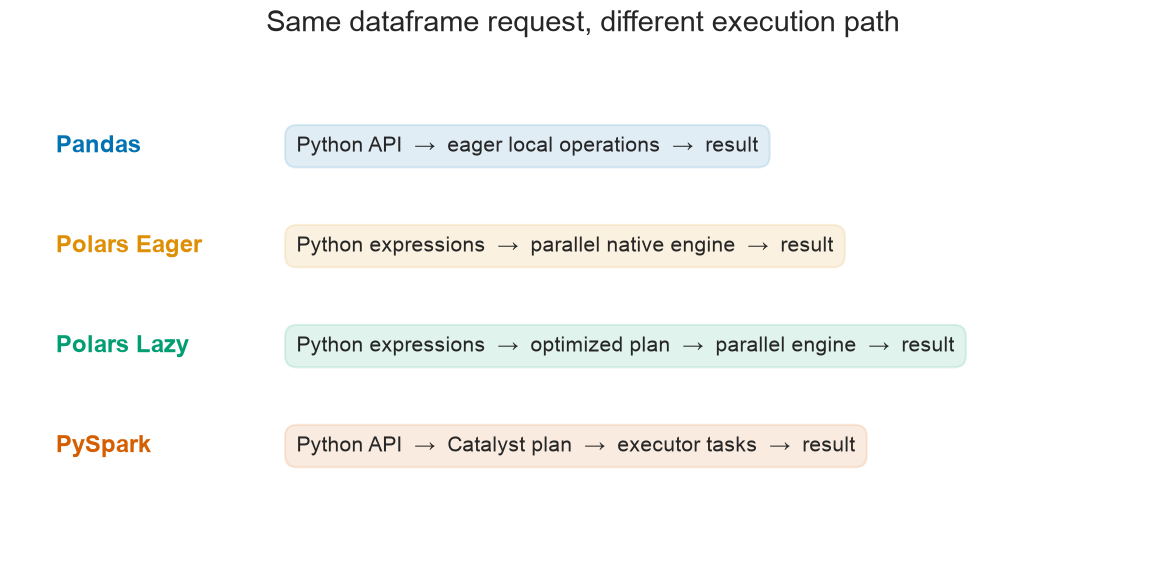

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")
paths = [
    ("Pandas", "Python API  →  eager local operations  →  result", "Pandas"),
    (
        "Polars Eager",
        "Python expressions  →  parallel native engine  →  result",
        "Polars Eager",
    ),
    (
        "Polars Lazy",
        "Python expressions  →  optimized plan  →  parallel engine  →  result",
        "Polars Lazy",
    ),
    (
        "PySpark",
        "Python API  →  Catalyst plan  →  executor tasks  →  result",
        "PySpark",
    ),
]
for y, (framework, path, color_key) in zip([0.82, 0.62, 0.42, 0.22], paths):
    color = FRAMEWORK_COLORS[color_key]
    ax.text(0.04, y, framework, fontsize=17, weight="bold", color=color, va="center")
    ax.text(
        0.25,
        y,
        path,
        fontsize=15,
        va="center",
        bbox=dict(
            boxstyle="round,pad=.55", facecolor=color, alpha=0.12, edgecolor=color
        ),
    )
ax.set_title("Same dataframe request, different execution path", fontsize=21, pad=18)
plt.tight_layout()
plt.show()

## 7. Choose from constraints—not from the benchmark winner

**Guiding question:** What additional facts do we need before selecting an engine for each workload?

Pause before revealing the guide. For each scenario, identify the missing constraints that could change your recommendation:

1. Interactive exploration of a 5 GB file by a team with an established Pandas workflow.
2. A repeated 100 GB analytical pipeline on one strong machine.
3. A multi-terabyte scheduled job that must scale beyond one machine.

<details>
<summary><strong>Reveal and discuss the conditional guide</strong></summary>

- **Pandas** may fit scenario 1 if the working set fits memory and ecosystem compatibility matters most.
- **Polars Lazy** is a strong candidate for scenario 2 if its planned or streaming execution keeps memory bounded and supports the required operations.
- **PySpark** is a strong candidate for scenario 3 if cluster infrastructure, distributed execution, and fault recovery justify its coordination cost.

These are starting hypotheses, not automatic answers. Ask about memory, input format, operation shape, concurrency, latency targets, deployment, team skills, and downstream integrations before deciding.

</details>

Speed is only one input. Reliability, maintainability, ecosystem fit, and operational cost can outweigh a benchmark result.

In [17]:
# Release the local Spark session after the demo.
if spark is not None:
    spark.stop()

## 8. Close the loop: from question to justified choice

**Guiding question:** What reasoning process should you reuse on your next dataframe workload?

1. **Define the analytical intent.** State the row meaning, operations, thresholds, and expected output.
2. **Make the data trustworthy.** Check the keys, missing values, duplicates, and transformations that could change the answer.
3. **Hold the workload constant.** Compare equivalent reads, operations, and materialization boundaries.
4. **Verify correctness before speed.** Equivalent-looking code must return equivalent results.
5. **Explain performance through architecture.** Ask where work runs, when it starts, and how it is organized.
6. **Choose for the real constraints.** Include memory, scale, deployment, ecosystem, reliability, and team experience.

```text
one trusted analytical question
              ↓
same workload and verified result
              ↓
Pandas: eager local | Polars: parallel local | PySpark: partitioned tasks
              ↓
a workload-based decision—not a universal benchmark winner
```

The transferable lesson is simple: choose the execution model that fits the workload you actually have.

## Optional appendix: let Polars plan before executing

**Guiding question:** What can Polars optimize when we describe the complete query before requesting a result?

This section sits **outside the 45-minute core demo**. It introduces a different timing model:

1. `scan_parquet` creates a lazy data source without loading the full result.
2. Expressions describe the complete transformation as a query plan.
3. Polars can optimize that plan, including reading only required columns.
4. `collect()` executes the optimized plan and materializes the answer.

This model is useful for the prepared 1B-row measurement because Polars can scan partitioned Parquet input without first constructing one enormous eager dataframe. Read the plan from the scan upward, then confirm that execution still reproduces the Pandas reference.

In [18]:
polars_lazy_query = (
    pl.scan_parquet(RATINGS_PATH)
    .select("movieId", "rating")
    .group_by("movieId")
    .agg(
        pl.col("rating").mean().alias("average_rating"),
        pl.len().alias("rating_count"),
    )
    .filter(pl.col("rating_count") >= MIN_RATINGS)
    .join(
        pl.scan_parquet(MOVIES_PATH).select("movieId", "title"),
        on="movieId",
    )
    .sort(
        ["average_rating", "rating_count", "movieId"],
        descending=[True, True, False],
    )
)

plan_lines = polars_lazy_query.explain(optimized=True).splitlines()
print("Optimized plan preview (no query result has been materialized yet):")
print("\n".join(plan_lines[:14]))

polars_lazy_result = polars_lazy_query.collect()
comparison_columns = ["movieId", "average_rating", "rating_count"]
pd.testing.assert_frame_equal(
    pandas_result[comparison_columns].sort_values("movieId").reset_index(drop=True),
    polars_lazy_result.select(comparison_columns)
    .sort("movieId")
    .to_pandas()
    .reset_index(drop=True),
    check_dtype=False,
    atol=1e-6,
    rtol=1e-6,
)
polars_lazy_result.head(TOP_N)

Optimized plan preview (no query result has been materialized yet):
SORT BY [descending: [true, true, false]] [col("average_rating"), col("rating_count"), col("movieId")]
  INNER JOIN:
  LEFT PLAN ON: [col("movieId")]
    FILTER col("rating_count") >= 1000
    FROM
      AGGREGATE[maintain_order: false]
        [col("rating").mean().alias("average_rating"), len().alias("rating_count")] BY [col("movieId")]
        FROM
        Parquet SCAN [/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/data/parquet/ratings_1m.parquet]
        PROJECT 2/4 COLUMNS
        ESTIMATED ROWS: 1000000
  RIGHT PLAN ON: [col("movieId")]
    Parquet SCAN [/Users/kedarvaidya/Downloads/data-processing-frameworks-demo/data/parquet/movies.parquet]
    PROJECT 2/3 COLUMNS


movieId,average_rating,rating_count,title
i32,f32,u32,str
318,4.375311,3212,"""Shawshank Redemption, The (199…"
858,4.31075,2000,"""Godfather, The (1972)"""
1221,4.268394,1332,"""Godfather: Part II, The (1974)"""
527,4.266581,2337,"""Schindler's List (1993)"""
50,4.242021,2068,"""Usual Suspects, The (1995)"""
5618,4.230067,1041,"""Spirited Away (Sen to Chihiro …"
1193,4.222101,1371,"""One Flew Over the Cuckoo's Nes…"
750,4.210318,1008,"""Dr. Strangelove or: How I Lear…"
2959,4.199122,2393,"""Fight Club (1999)"""
